# Hotel Booking Demand — canal alojamientos

EDA y modelos de **cancelación** y **ADR** como proxy de volumen/estacionalidad de huéspedes.

- Datos: `data/kaggle/hotel-booking/hotel_bookings.csv`
- Uso Culebra: proxy **referidos**, temporada y canal (no es turismo rural Zamora)
- Para rural ES preferid INE EOAT; este notebook practica el pipeline
- Mapa: `docs/Variables_Decision_Datasets_Kaggle.md`


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]


## Cargar dataset

In [2]:
here = Path.cwd()
candidates = [
    here / "hotel_bookings.csv",
    here / "data" / "kaggle" / "hotel-booking" / "hotel_bookings.csv",
    Path("/kaggle/input"),
]
path = None
for c in candidates:
    if c.is_file():
        path = c
        break
    if c.is_dir():
        found = list(c.rglob("hotel_bookings.csv"))
        if found:
            path = found[0]
            break
if path is None:
    raise FileNotFoundError("No se encuentra hotel_bookings.csv")

raw = pd.read_csv(path)
raw["children"] = raw["children"].fillna(0)
raw["agent"] = raw["agent"].fillna(0)
raw["company"] = raw["company"].fillna(0)
raw["country"] = raw["country"].fillna("UNK")
raw["total_nights"] = raw["stays_in_weekend_nights"] + raw["stays_in_week_nights"]
raw["guests"] = raw["adults"] + raw["children"] + raw["babies"]
raw["arrival_date_month"] = pd.Categorical(
    raw["arrival_date_month"], categories=MONTH_ORDER, ordered=True
)
print("Dataset path:", path.resolve())
print(raw.shape)
raw.head()


Dataset path: C:\Users\chuwi\Documents\culebra\data\kaggle\hotel-booking\hotel_bookings.csv
(119390, 34)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,guests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0


## Resumen rápido

In [3]:
confirmed = raw[raw["is_canceled"] == 0]
print("Reservas:", len(raw))
print("% canceladas:", round(raw["is_canceled"].mean() * 100, 1))
print("ADR medio (todas):", round(raw["adr"].mean(), 2))
print("ADR medio (no canceladas):", round(confirmed["adr"].mean(), 2))
print("Huéspedes medios (no canceladas):", round(confirmed["guests"].mean(), 2))
print("Noches medias (no canceladas):", round(confirmed["total_nights"].mean(), 2))
display(raw[["lead_time", "adr", "total_nights", "guests", "is_canceled"]].describe().round(2))


Reservas: 119390
% canceladas: 37.0
ADR medio (todas): 101.83
ADR medio (no canceladas): 99.99
Huéspedes medios (no canceladas): 1.94
Noches medias (no canceladas): 3.39


,lead_time,adr,total_nights,guests,is_canceled
count,119390.00,119390.00,119390.00,119390.00,119390.00
mean,104.01,101.83,3.43,1.97,0.37
std,106.86,50.54,2.56,0.72,0.48
min,0.00,-6.38,0.00,0.00,0.00
25%,18.00,69.29,2.00,2.00,0.00
50%,69.00,94.58,3.00,2.00,0.00
75%,160.00,126.00,4.00,2.00,1.00
max,737.00,5400.00,69.00,55.00,1.00


## Estacionalidad — llegadas y ADR (proxy visitas referidos)

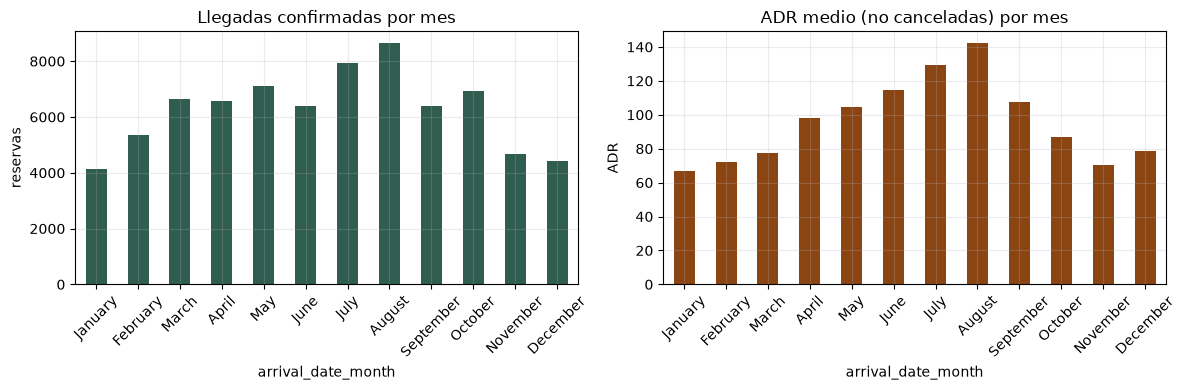

Meses pico (arrivals) → priorizar material L2 / welcome packs en CRM Culebra:


,arrivals,adr,guests
arrival_date_month,,,
August,8638,142.1,19138.0
July,7919,129.3,17317.0
May,7114,104.8,13442.0
October,6914,86.8,12720.0


In [4]:
monthly = (
    confirmed.groupby("arrival_date_month", observed=True)
    .agg(arrivals=("hotel", "count"), adr=("adr", "mean"), guests=("guests", "sum"))
    .reindex(MONTH_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
monthly["arrivals"].plot(kind="bar", ax=axes[0], color="#2f5d50", rot=45)
axes[0].set_title("Llegadas confirmadas por mes")
axes[0].set_ylabel("reservas")

monthly["adr"].plot(kind="bar", ax=axes[1], color="#8b4513", rot=45)
axes[1].set_title("ADR medio (no canceladas) por mes")
axes[1].set_ylabel("ADR")
plt.tight_layout()
plt.show()

print("Meses pico (arrivals) → priorizar material L2 / welcome packs en CRM Culebra:")
display(monthly.sort_values("arrivals", ascending=False).head(4).round(1))


## Canal y segmento de mercado

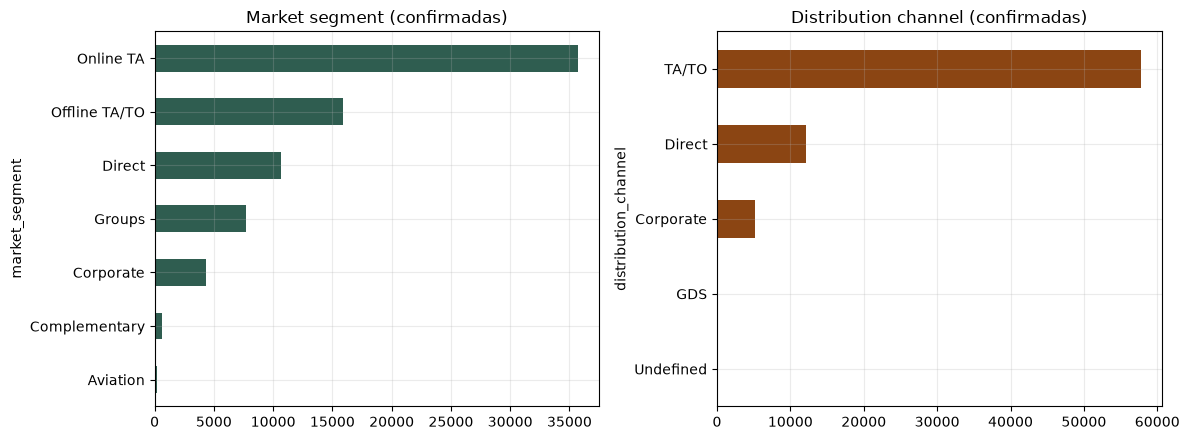

Proxy Culebra: Direct / Offline TA ≈ partners activos; Online TA ≈ tráfico genérico


,n,adr,nights
market_segment,,,
Online TA,35738,113.86,3.33
Offline TA/TO,15908,83.42,4.26
Direct,10672,113.88,3.08
Groups,7714,77.12,3.23
Corporate,4303,67.11,2.00
Complementary,646,3.08,1.69
Aviation,185,99.48,3.74


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
confirmed["market_segment"].value_counts().head(8).sort_values().plot(
    kind="barh", ax=axes[0], color="#2f5d50"
)
axes[0].set_title("Market segment (confirmadas)")

confirmed["distribution_channel"].value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color="#8b4513"
)
axes[1].set_title("Distribution channel (confirmadas)")
plt.tight_layout()
plt.show()

seg = (
    confirmed.groupby("market_segment")
    .agg(n=("hotel", "count"), adr=("adr", "mean"), nights=("total_nights", "mean"))
    .sort_values("n", ascending=False)
    .head(8)
    .round(2)
)
print("Proxy Culebra: Direct / Offline TA ≈ partners activos; Online TA ≈ tráfico genérico")
display(seg)


## Hotel type × cancelación (volumen neto de huéspedes)

,n,cancel_rate,adr
hotel,,,
City Hotel,79330,0.417,105.304
Resort Hotel,40060,0.278,94.953


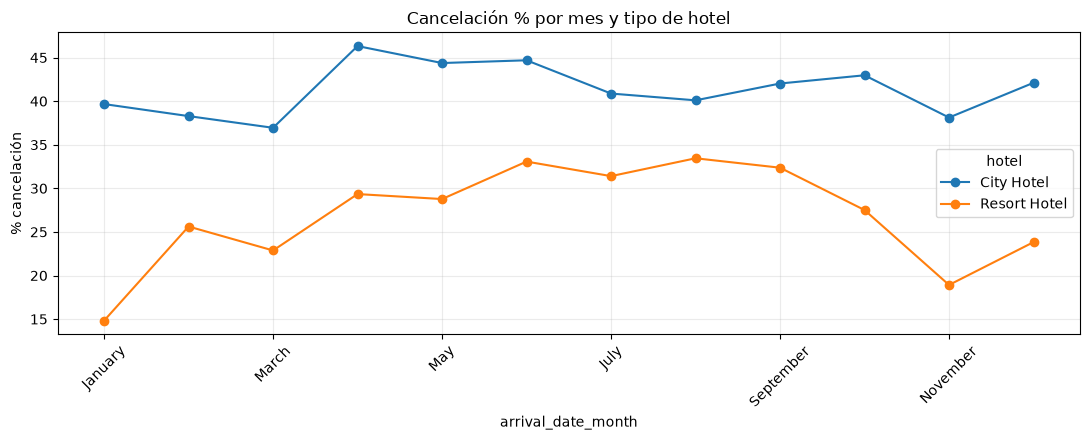

In [6]:
by_hotel = raw.groupby("hotel").agg(
    n=("is_canceled", "count"),
    cancel_rate=("is_canceled", "mean"),
    adr=("adr", "mean"),
).round(3)
display(by_hotel)

fig, ax = plt.subplots()
raw.groupby(["arrival_date_month", "hotel"], observed=True)["is_canceled"].mean().unstack().reindex(
    MONTH_ORDER
).mul(100).plot(ax=ax, marker="o")
ax.set_ylabel("% cancelación")
ax.set_title("Cancelación % por mes y tipo de hotel")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Proxy referidos Culebra

Estimación ilustrativa: huéspedes confirmados × tasa de derivación al showroom.
(En panel real usáis `referred_visits` / `baskets_via` del CRM.)

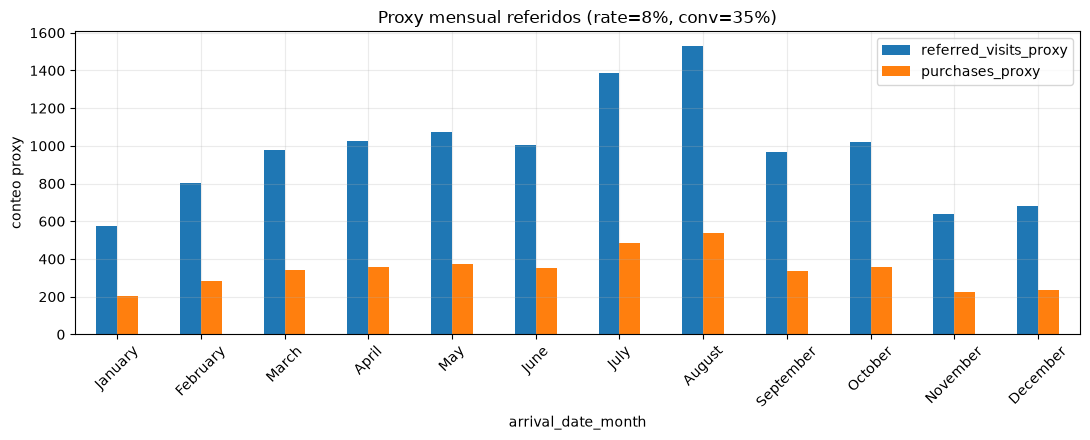

,arrivals,guests,referred_visits_proxy,purchases_proxy
arrival_date_month,,,,
January,4122,7186.0,575.0,201.0
February,5372,10029.0,802.0,281.0
March,6645,12245.0,980.0,343.0
April,6565,12833.0,1027.0,359.0
May,7114,13442.0,1075.0,376.0
June,6404,12520.0,1002.0,351.0
July,7919,17317.0,1385.0,485.0
August,8638,19138.0,1531.0,536.0
September,6392,12068.0,965.0,338.0


In [7]:
REFERRAL_RATE = 0.08  # hipótesis: 8% de huéspedes visitan showroom / partner
CONV_SHOWROOM = 0.35  # meta conversión showroom

proxy = monthly.copy()
proxy["referred_visits_proxy"] = (proxy["guests"] * REFERRAL_RATE).round(0)
proxy["purchases_proxy"] = (proxy["referred_visits_proxy"] * CONV_SHOWROOM).round(0)

fig, ax = plt.subplots()
proxy[["referred_visits_proxy", "purchases_proxy"]].plot(kind="bar", ax=ax, rot=45)
ax.set_title(f"Proxy mensual referidos (rate={REFERRAL_RATE:.0%}, conv={CONV_SHOWROOM:.0%})")
ax.set_ylabel("conteo proxy")
plt.tight_layout()
plt.show()
display(proxy[["arrivals", "guests", "referred_visits_proxy", "purchases_proxy"]].head(12))


## Modelo: predecir cancelación

In [8]:
# Muestra para velocidad en portátiles
df = raw.sample(n=min(40000, len(raw)), random_state=42)

cat_cols = ["hotel", "market_segment", "distribution_channel", "deposit_type", "customer_type", "arrival_date_month"]
num_cols = [
    "lead_time", "total_nights", "guests", "previous_cancellations",
    "booking_changes", "days_in_waiting_list", "total_of_special_requests",
    "is_repeated_guest", "required_car_parking_spaces",
]
X = df[cat_cols + num_cols]
y = df["is_canceled"]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)
clf = Pipeline(
    [
        ("pre", pre),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print("Accuracy cancelación:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred, digits=3))


Accuracy cancelación: 0.823
              precision    recall  f1-score   support

           0      0.841     0.886     0.863      6285
           1      0.788     0.715     0.750      3715

    accuracy                          0.823     10000
   macro avg      0.814     0.801     0.806     10000
weighted avg      0.821     0.823     0.821     10000



## Modelo: predecir ADR (regresión, no canceladas)

MAE ADR: 17.28
R²: 0.68


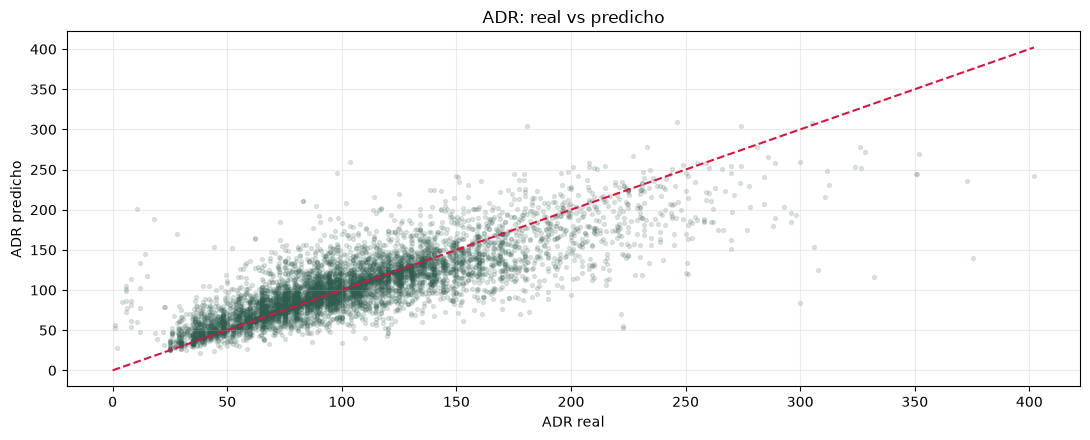

In [9]:
df_ok = confirmed.sample(n=min(30000, len(confirmed)), random_state=42)
df_ok = df_ok[df_ok["adr"] > 0]
X = df_ok[cat_cols + num_cols]
y = df_ok["adr"]

reg = Pipeline(
    [
        ("pre", pre),
        ("rf", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ]
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
print("MAE ADR:", round(mean_absolute_error(y_test, pred), 2))
print("R²:", round(r2_score(y_test, pred), 3))

fig, ax = plt.subplots()
ax.scatter(y_test, pred, alpha=0.15, s=8, color="#2f5d50")
lim = [0, max(y_test.max(), pred.max())]
ax.plot(lim, lim, color="crimson", ls="--")
ax.set_xlabel("ADR real")
ax.set_ylabel("ADR predicho")
ax.set_title("ADR: real vs predicho")
plt.tight_layout()
plt.show()


## Conclusiones para decidir (Culebra)

1. **Picos mensuales** de llegadas → intensificar material L2 y welcome packs (CRM `/admin/turismo`).
2. **Canal Direct** es el proxy más cercano a partners activos; Online TA no equivale a L3–L4.
3. Cancelación alta reduce huéspedes netos: el proxy de referidos debe usar **confirmadas**, no brutas.
4. ADR y lead_time ayudan a anticipar temporada; calibrar con **INE EOAT** CyL y contadores reales `referred_visits`.
5. No usar cifras absolutas de este dataset como forecast de Villardeciervos.
